# 期末综合实验：完整数字通信系统设计与实现

本 notebook 完成一个端到端数字通信系统：

`语音采样/量化/编码 -> 信道编码 -> 数字调制 -> RRC 基带成形 -> 500 kHz 频带调制 -> 500 kHz ± 100 kHz 限带 AWGN 信道 -> 相干解调/匹配滤波 -> 判决译码 -> 语音恢复`

四个探究问题全部完成：

1. 不同调制方式的性能比较；
2. 信道编码的作用分析；
3. 量化位数对语音恢复质量的影响；
4. 系统瓶颈分析。

使用方法：

1. 把自己的录音 `.wav` 放在本 notebook 同目录，推荐命名为 `my_voice.wav`。
2. 从上到下运行所有单元格。
3. 如果没有录音，notebook 会自动生成一段类语音测试信号。

## 1. 系统总体方案和框图

```text
原始语音
  -> 采样/重采样到 8 kHz
  -> 均匀 PCM 量化
  -> 比特流
  -> 可选 Hamming(7,4) 信道编码
  -> BPSK / QPSK / 8PSK / 16QAM 调制
  -> RRC FIR 成形滤波
  -> 500 kHz 载波调制
  -> 500 kHz ± 100 kHz 限带 AWGN 信道
  -> 相干下变频
  -> RRC 匹配滤波
  -> 星座判决
  -> 可选 Hamming(7,4) 译码
  -> PCM 反量化
  -> 恢复语音
```

本实验沿用“信号分析与处理”课程中的两类基础算法：

- **信号频谱分析模块**：对信号加 Hann 窗后做 FFT，使用 `fftshift` 得到双边频谱，并以归一化 dB 显示频谱幅度。
- **数字基带成形与匹配滤波模块**：按照 FIR 设计思想实现。RRC 成形/匹配滤波器由根升余弦冲激响应截断得到；限带信道滤波器由窗函数法设计，即两个低通 sinc FIR 相减得到带通 FIR。

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, Markdown, display

warnings.filterwarnings("ignore", category=RuntimeWarning)

AUDIO_FS = 8_000
MAX_SECONDS = 0.8
FC = 500_000.0
CHANNEL_BW = 200_000.0
F_LO = FC - CHANNEL_BW / 2
F_HI = FC + CHANNEL_BW / 2
FS_PASS = 1_344_000.0
ROLL_OFF = 0.25
RRC_SPAN = 8
BASELINE_SNR_DB = 18.0
EXPLORE_SNR_DB = 12.0
RNG_SEED = 20260614

MOD_BITS = {"BPSK": 1, "QPSK": 2, "8PSK": 3, "16QAM": 4}

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

## 2. 语音读取与预处理

程序优先读取当前目录或 `hw3` 目录中的 `my_voice.wav`。若不存在录音，则生成一段带包络和谐波结构的测试信号。

In [2]:
def _wav_to_float(data: np.ndarray) -> np.ndarray:
    '把 wavfile.read 得到的整数或浮点数组转换到 [-1, 1] 附近。'
    if data.ndim > 1:
        data = data.mean(axis=1)
    if np.issubdtype(data.dtype, np.integer):
        info = np.iinfo(data.dtype)
        scale = max(abs(info.min), abs(info.max))
        x = data.astype(np.float64) / scale
    else:
        x = data.astype(np.float64)
    x = np.nan_to_num(x)
    return 0.95 * x / (np.max(np.abs(x)) + 1e-12)


def _resample_to_target(x: np.ndarray, fs: int, target_fs: int) -> np.ndarray:
    if fs == target_fs:
        return x
    g = math.gcd(int(fs), int(target_fs))
    return signal.resample_poly(x, target_fs // g, fs // g)


def windowed_lowpass(cutoff_hz: float, fs: float, numtaps: int) -> np.ndarray:
    '窗函数法低通 FIR：理想 sinc 低通 * Hamming 窗。'
    if numtaps % 2 == 0:
        raise ValueError("numtaps should be odd for integer group delay.")
    n = np.arange(numtaps) - (numtaps - 1) / 2
    h = 2 * cutoff_hz / fs * np.sinc(2 * cutoff_hz * n / fs)
    h *= np.hamming(numtaps)
    h /= np.sum(h)
    return h


def synthesize_demo_voice(fs: int, seconds: float) -> np.ndarray:
    '生成一段轻量的类语音信号，仅用于没有录音文件时的演示。'
    rng = np.random.default_rng(RNG_SEED)
    t = np.arange(int(fs * seconds)) / fs
    f0 = 135 + 28 * np.sin(2 * np.pi * 1.7 * t)
    phase = 2 * np.pi * np.cumsum(f0) / fs
    harmonic = (
        0.62 * np.sin(phase)
        + 0.24 * np.sin(2 * phase + 0.4)
        + 0.12 * np.sin(3 * phase + 1.1)
    )
    formant_like = (
        0.22 * np.sin(2 * np.pi * 620 * t)
        + 0.12 * np.sin(2 * np.pi * 1180 * t + 0.5)
    )
    syllable_env = 0.35 + 0.65 * (np.sin(2 * np.pi * 2.3 * t) ** 2)
    fade = np.minimum(1, np.minimum(t / 0.04, (seconds - t) / 0.04))
    noise = 0.015 * rng.standard_normal(len(t))
    x = (harmonic + formant_like + noise) * syllable_env * np.clip(fade, 0, 1)
    b = windowed_lowpass(3400, fs, 129)
    x = signal.lfilter(b, [1.0], x)
    return 0.95 * x / (np.max(np.abs(x)) + 1e-12)


def find_audio_candidates() -> list[Path]:
    roots = [Path.cwd()]
    if Path.cwd().name.lower() != "hw3" and (Path.cwd() / "hw3").exists():
        roots.append(Path.cwd() / "hw3")
    preferred = []
    others = []
    for root in roots:
        preferred.extend([root / "my_voice.wav", root / "voice.wav", root / "speech.wav"])
        others.extend(sorted(root.glob("*.wav")))
    seen = set()
    candidates = []
    for p in preferred + others:
        if p.exists():
            key = str(p.resolve())
            if key not in seen:
                candidates.append(p)
                seen.add(key)
    return candidates


def load_or_make_voice(target_fs: int = AUDIO_FS, max_seconds: float = MAX_SECONDS):
    candidates = find_audio_candidates()
    if candidates:
        path = candidates[0]
        fs, data = wavfile.read(path)
        x = _wav_to_float(data)
        x = _resample_to_target(x, fs, target_fs)
        source = f"读取录音：{path}"
    else:
        x = synthesize_demo_voice(target_fs, max_seconds)
        source = "未找到 my_voice.wav，使用合成类语音演示信号"
    n = int(target_fs * max_seconds)
    if len(x) < n:
        x = np.pad(x, (0, n - len(x)))
    else:
        x = x[:n]
    x = x - np.mean(x)
    x = 0.95 * x / (np.max(np.abs(x)) + 1e-12)
    return x.astype(np.float64), target_fs, source

## 3. 频谱分析与 FIR 滤波器设计

这里给出频谱分析、窗函数法带通 FIR、RRC 成形滤波器三个公共模块。

In [3]:
def spectrum_db(x: np.ndarray, fs: float, nfft: int = 65536):
    '加窗 FFT 频谱分析，返回频率轴和归一化幅度 dB。'
    x = np.asarray(x)
    n = min(len(x), nfft)
    seg = x[:n]
    win = np.hanning(n)
    X = np.fft.fftshift(np.fft.fft(seg * win, nfft))
    f = np.fft.fftshift(np.fft.fftfreq(nfft, d=1 / fs))
    mag = np.abs(X)
    db = 20 * np.log10(mag / (np.max(mag) + 1e-15) + 1e-12)
    return f, db


def windowed_bandpass(f_lo: float, f_hi: float, fs: float, numtaps: int, center_hz: float | None = None):
    '窗函数法带通 FIR：两个低通 FIR 相减，并可在中心频率归一化增益。'
    h = windowed_lowpass(f_hi, fs, numtaps) - windowed_lowpass(f_lo, fs, numtaps)
    if center_hz is not None:
        n = np.arange(numtaps)
        gain = abs(np.sum(h * np.exp(-1j * 2 * np.pi * center_hz * n / fs)))
        h = h / (gain + 1e-15)
    return h


def rrc_filter(beta: float, span_symbols: int, sps: int) -> np.ndarray:
    '根升余弦 FIR 滤波器。span_symbols 为总跨度，sps 为每符号采样点数。'
    n = np.arange(-span_symbols * sps / 2, span_symbols * sps / 2 + 1)
    tau = n / sps
    h = np.zeros_like(tau, dtype=np.float64)
    for i, t in enumerate(tau):
        if abs(t) < 1e-12:
            h[i] = 1 + beta * (4 / np.pi - 1)
        elif beta > 0 and abs(abs(t) - 1 / (4 * beta)) < 1e-12:
            h[i] = (beta / np.sqrt(2)) * (
                (1 + 2 / np.pi) * np.sin(np.pi / (4 * beta))
                + (1 - 2 / np.pi) * np.cos(np.pi / (4 * beta))
            )
        else:
            numerator = (
                np.sin(np.pi * t * (1 - beta))
                + 4 * beta * t * np.cos(np.pi * t * (1 + beta))
            )
            denominator = np.pi * t * (1 - (4 * beta * t) ** 2)
            h[i] = numerator / denominator
    h /= np.sqrt(np.sum(h**2))
    return h

## 4. 量化、Hamming(7,4) 信道编码与数字调制

量化采用均匀 PCM。信道编码可开关：开启时使用 Hamming(7,4)，每 4 个信息比特生成 7 个码比特，可纠正单比特错误。调制模块支持 BPSK、QPSK、8PSK 和 16QAM。

In [4]:
def ints_to_bits(values: np.ndarray, nbits: int) -> np.ndarray:
    values = np.asarray(values, dtype=np.int64)
    shifts = np.arange(nbits - 1, -1, -1)
    return ((values[:, None] >> shifts) & 1).astype(np.uint8).reshape(-1)


def bits_to_ints(bits: np.ndarray, nbits: int) -> np.ndarray:
    bits = np.asarray(bits, dtype=np.uint8)
    usable = (len(bits) // nbits) * nbits
    shaped = bits[:usable].reshape(-1, nbits)
    weights = (1 << np.arange(nbits - 1, -1, -1)).astype(np.int64)
    return (shaped * weights).sum(axis=1).astype(np.int64)


def quantize_pcm(x: np.ndarray, nbits: int):
    levels = 1 << nbits
    clipped = np.clip(x, -1, 1 - 1e-12)
    codes = np.floor((clipped + 1) * levels / 2).astype(np.int64)
    codes = np.clip(codes, 0, levels - 1)
    bits = ints_to_bits(codes, nbits)
    xq = (codes + 0.5) / levels * 2 - 1
    return bits, codes, xq


def dequantize_pcm(bits: np.ndarray, nbits: int, nsamples: int) -> np.ndarray:
    codes = bits_to_ints(bits, nbits)[:nsamples]
    levels = 1 << nbits
    return (codes + 0.5) / levels * 2 - 1


def hamming74_encode(bits: np.ndarray):
    bits = np.asarray(bits, dtype=np.uint8)
    pad = (-len(bits)) % 4
    if pad:
        bits = np.pad(bits, (0, pad))
    d = bits.reshape(-1, 4)
    d1, d2, d3, d4 = d[:, 0], d[:, 1], d[:, 2], d[:, 3]
    p1 = d1 ^ d2 ^ d4
    p2 = d1 ^ d3 ^ d4
    p4 = d2 ^ d3 ^ d4
    codewords = np.column_stack([p1, p2, d1, p4, d2, d3, d4]).astype(np.uint8)
    return codewords.reshape(-1), pad


def hamming74_decode(bits: np.ndarray, pad: int = 0):
    bits = np.asarray(bits, dtype=np.uint8)
    usable = (len(bits) // 7) * 7
    cw = bits[:usable].reshape(-1, 7).copy()
    s1 = cw[:, 0] ^ cw[:, 2] ^ cw[:, 4] ^ cw[:, 6]
    s2 = cw[:, 1] ^ cw[:, 2] ^ cw[:, 5] ^ cw[:, 6]
    s4 = cw[:, 3] ^ cw[:, 4] ^ cw[:, 5] ^ cw[:, 6]
    err_pos = s1 + 2 * s2 + 4 * s4
    rows = np.where(err_pos > 0)[0]
    if len(rows):
        cw[rows, err_pos[rows] - 1] ^= 1
    data = cw[:, [2, 4, 5, 6]].reshape(-1)
    if pad:
        data = data[:-pad]
    return data.astype(np.uint8)


def _pack_bits(bits: np.ndarray, k: int):
    bits = np.asarray(bits, dtype=np.uint8)
    pad = (-len(bits)) % k
    if pad:
        bits = np.pad(bits, (0, pad))
    return bits.reshape(-1, k), pad


def _gray_sequence(k: int):
    return [i ^ (i >> 1) for i in range(1 << k)]


def modulate_bits(bits: np.ndarray, scheme: str):
    scheme = scheme.upper()
    k = MOD_BITS[scheme]
    groups, pad = _pack_bits(bits, k)
    idx = (groups * (1 << np.arange(k - 1, -1, -1))).sum(axis=1)

    if scheme == "BPSK":
        symbols = 1.0 - 2.0 * idx.astype(np.float64)
        return symbols.astype(np.complex128), pad

    if scheme == "QPSK":
        i = 1.0 - 2.0 * groups[:, 0].astype(np.float64)
        q = 1.0 - 2.0 * groups[:, 1].astype(np.float64)
        return (i + 1j * q) / np.sqrt(2), pad

    if scheme == "8PSK":
        gray = np.array(_gray_sequence(3))
        natural = np.array([np.where(gray == v)[0][0] for v in idx])
        phase = 2 * np.pi * natural / 8 + np.pi / 8
        return np.exp(1j * phase), pad

    if scheme == "16QAM":
        level_map = {
            0b00: -3,
            0b01: -1,
            0b11: 1,
            0b10: 3,
        }
        i_idx = groups[:, 0] * 2 + groups[:, 1]
        q_idx = groups[:, 2] * 2 + groups[:, 3]
        i = np.array([level_map[int(v)] for v in i_idx], dtype=np.float64)
        q = np.array([level_map[int(v)] for v in q_idx], dtype=np.float64)
        return (i + 1j * q) / np.sqrt(10), pad

    raise ValueError(f"Unsupported scheme: {scheme}")


def demodulate_symbols(symbols: np.ndarray, scheme: str):
    scheme = scheme.upper()

    if scheme == "BPSK":
        return (np.real(symbols) < 0).astype(np.uint8)

    if scheme == "QPSK":
        b0 = (np.real(symbols) < 0).astype(np.uint8)
        b1 = (np.imag(symbols) < 0).astype(np.uint8)
        return np.column_stack([b0, b1]).reshape(-1)

    if scheme == "8PSK":
        gray = np.array(_gray_sequence(3), dtype=np.uint8)
        const = np.exp(1j * (2 * np.pi * np.arange(8) / 8 + np.pi / 8))
        nearest = np.argmin(np.abs(symbols[:, None] - const[None, :]) ** 2, axis=1)
        labels = gray[nearest]
        return ints_to_bits(labels, 3)

    if scheme == "16QAM":
        levels = np.array([-3, -1, 1, 3], dtype=np.float64) / np.sqrt(10)
        bits_for_level = {
            0: [0, 0],
            1: [0, 1],
            2: [1, 1],
            3: [1, 0],
        }
        i_near = np.argmin(np.abs(np.real(symbols)[:, None] - levels[None, :]), axis=1)
        q_near = np.argmin(np.abs(np.imag(symbols)[:, None] - levels[None, :]), axis=1)
        out = np.empty((len(symbols), 4), dtype=np.uint8)
        for n in range(len(symbols)):
            out[n, :2] = bits_for_level[int(i_near[n])]
            out[n, 2:] = bits_for_level[int(q_near[n])]
        return out.reshape(-1)

    raise ValueError(f"Unsupported scheme: {scheme}")

## 5. 限带 AWGN 信道与端到端仿真函数

发送端把复基带信号调制到 500 kHz；信道用带通 FIR 限制到 `500 kHz ± 100 kHz`，然后加入同频带 AWGN。接收端采用理想载波同步和已知群时延的基准假设。

In [5]:
FILTER_CACHE = {}


def add_bandlimited_awgn(x: np.ndarray, fs: float, snr_db: float, h_band: np.ndarray, rng: np.random.Generator):
    noise = rng.standard_normal(len(x))
    noise = signal.lfilter(h_band, [1.0], noise)
    signal_power = np.mean(x**2) + 1e-15
    noise_power = np.mean(noise**2) + 1e-15
    target_noise_power = signal_power / (10 ** (snr_db / 10))
    return x + noise * np.sqrt(target_noise_power / noise_power)


def _get_filters(sps: int):
    if sps not in FILTER_CACHE:
        h_rrc = rrc_filter(ROLL_OFF, RRC_SPAN, sps)
        h_channel = windowed_bandpass(F_LO, F_HI, FS_PASS, 257, center_hz=FC)
        FILTER_CACHE[sps] = (h_rrc, h_channel)
    return FILTER_CACHE[sps]


def simulate_system(
    audio: np.ndarray,
    nbits: int = 8,
    snr_db: float = BASELINE_SNR_DB,
    modulation: str = "QPSK",
    use_coding: bool = True,
    keep_traces: bool = False,
):
    modulation = modulation.upper()
    source_bits, _, quantized_only = quantize_pcm(audio, nbits)

    if use_coding:
        tx_bits, hamming_pad = hamming74_encode(source_bits)
        coding_name = "Hamming(7,4)"
    else:
        tx_bits = source_bits.copy()
        hamming_pad = 0
        coding_name = "None"

    symbols, mod_pad = modulate_bits(tx_bits, modulation)
    bits_per_symbol = MOD_BITS[modulation]

    source_bitrate = AUDIO_FS * nbits
    tx_bitrate = source_bitrate * (7 / 4 if use_coding else 1.0)
    symbol_rate = tx_bitrate / bits_per_symbol
    sps_float = FS_PASS / symbol_rate
    sps = int(round(sps_float))
    if abs(sps_float - sps) > 1e-9:
        raise ValueError(f"FS_PASS={FS_PASS} 与 {modulation} 的符号率不成整数采样点。")

    h_rrc, h_channel = _get_filters(sps)
    rrc_delay = (len(h_rrc) - 1) // 2
    channel_delay = (len(h_channel) - 1) // 2

    tx_bb = signal.upfirdn(h_rrc, symbols, up=sps)
    tx_bb = np.pad(tx_bb, (0, channel_delay + len(h_rrc) + sps))

    t = np.arange(len(tx_bb)) / FS_PASS
    tx_pass = np.sqrt(2) * np.real(tx_bb * np.exp(1j * 2 * np.pi * FC * t))

    channel_out = signal.lfilter(h_channel, [1.0], tx_pass)
    rng = np.random.default_rng(RNG_SEED + nbits * 31 + int(snr_db * 10) + len(modulation) * 17 + int(use_coding))
    rx_pass = add_bandlimited_awgn(channel_out, FS_PASS, snr_db, h_channel, rng)

    carrier = np.exp(-1j * 2 * np.pi * FC * t)
    phase_correction = np.exp(1j * 2 * np.pi * FC * channel_delay / FS_PASS)
    rx_mixed = np.sqrt(2) * rx_pass * carrier * phase_correction
    rx_mf = signal.lfilter(h_rrc, [1.0], rx_mixed)

    sample_start = 2 * rrc_delay + channel_delay
    rx_symbols = rx_mf[sample_start : sample_start + len(symbols) * sps : sps]
    rx_symbols = rx_symbols[: len(symbols)]

    rx_tx_bits = demodulate_symbols(rx_symbols, modulation)[: len(tx_bits)]
    if use_coding:
        decoded_bits = hamming74_decode(rx_tx_bits, hamming_pad)[: len(source_bits)]
    else:
        decoded_bits = rx_tx_bits[: len(source_bits)]

    recovered = dequantize_pcm(decoded_bits, nbits, len(audio))
    tx_bit_ber = float(np.mean(rx_tx_bits != tx_bits))
    source_ber = float(np.mean(decoded_bits != source_bits))
    mse = float(np.mean((audio - recovered) ** 2))
    rec_snr = float(10 * np.log10((np.mean(audio**2) + 1e-15) / (mse + 1e-15)))
    quant_mse = float(np.mean((audio - quantized_only) ** 2))
    quant_snr = float(10 * np.log10((np.mean(audio**2) + 1e-15) / (quant_mse + 1e-15)))
    occupied_bw = (1 + ROLL_OFF) * symbol_rate

    result = {
        "nbits": nbits,
        "snr_db": snr_db,
        "modulation": modulation,
        "bits_per_symbol": bits_per_symbol,
        "use_coding": use_coding,
        "coding_name": coding_name,
        "source_bitrate_bps": source_bitrate,
        "tx_bitrate_bps": tx_bitrate,
        "symbol_rate_baud": symbol_rate,
        "sps": sps,
        "occupied_bw_hz": occupied_bw,
        "fits_channel": occupied_bw <= CHANNEL_BW,
        "spectral_efficiency_bps_per_hz": source_bitrate / occupied_bw,
        "tx_bit_ber_before_decoding": tx_bit_ber,
        "source_ber_after_decoding": source_ber,
        "quantization_snr_db": quant_snr,
        "recovered_snr_db": rec_snr,
        "quantized_only": quantized_only,
        "recovered": recovered,
    }
    if keep_traces:
        result.update(
            {
                "source_bits": source_bits,
                "tx_bits": tx_bits,
                "symbols": symbols,
                "rx_symbols": rx_symbols,
                "tx_bb": tx_bb,
                "tx_pass": tx_pass,
                "rx_pass": rx_pass,
                "rx_mf": rx_mf,
                "h_rrc": h_rrc,
                "h_channel": h_channel,
            }
        )
    return result


def result_row(r: dict):
    return {
        "量化位数": r["nbits"],
        "调制": r["modulation"],
        "编码": r["coding_name"],
        "SNR/dB": r["snr_db"],
        "源比特率/kbps": r["source_bitrate_bps"] / 1e3,
        "发送比特率/kbps": r["tx_bitrate_bps"] / 1e3,
        "符号率/kbaud": r["symbol_rate_baud"] / 1e3,
        "占用带宽/kHz": r["occupied_bw_hz"] / 1e3,
        "频谱效率/bps/Hz": r["spectral_efficiency_bps_per_hz"],
        "译码前BER": r["tx_bit_ber_before_decoding"],
        "译码后BER": r["source_ber_after_decoding"],
        "量化SNR/dB": r["quantization_snr_db"],
        "恢复SNR/dB": r["recovered_snr_db"],
        "满足200kHz": r["fits_channel"],
    }

## 6. 读取语音并试听

读取录音：D:\steven\hw\txyl\hw3\my_voice.wav
语音采样率: 8000 Hz, 样本数: 6400, 时长: 0.80 s


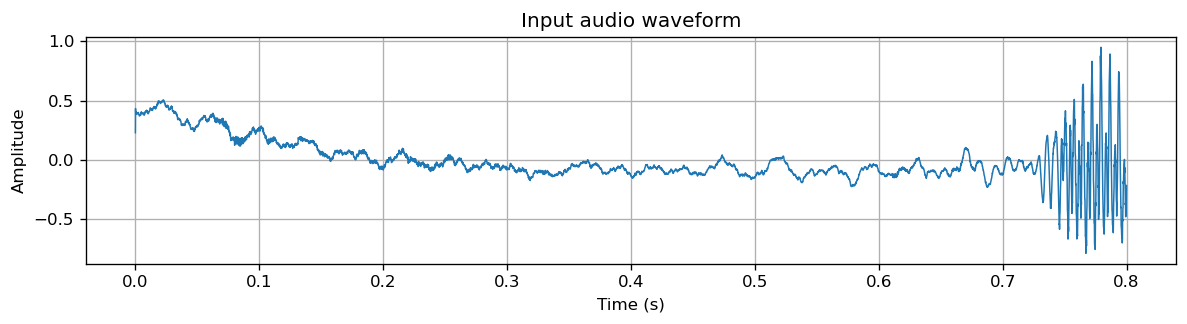

In [6]:
audio, audio_fs, audio_source = load_or_make_voice()
print(audio_source)
print(f"语音采样率: {audio_fs} Hz, 样本数: {len(audio)}, 时长: {len(audio) / audio_fs:.2f} s")
display(Audio(audio, rate=audio_fs))

t_audio = np.arange(len(audio)) / audio_fs
plt.figure(figsize=(10, 2.8))
plt.plot(t_audio, audio, lw=0.9)
plt.title("Input audio waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## 7. 基础实验结果：8 bit + Hamming(7,4) + QPSK

先用 8 bit 量化、Hamming(7,4) 编码和 QPSK 调制作为基础系统，观察发送端/接收端关键波形、发送信号频谱和语音恢复效果。

In [7]:
baseline = simulate_system(audio, nbits=8, snr_db=BASELINE_SNR_DB, modulation="QPSK", use_coding=True, keep_traces=True)

baseline_summary = pd.DataFrame(
    [
        ["量化位数", f"{baseline['nbits']} bit"],
        ["信道编码", baseline["coding_name"]],
        ["调制方式", baseline["modulation"]],
        ["信道 SNR", f"{baseline['snr_db']:.1f} dB"],
        ["信息比特率", f"{baseline['source_bitrate_bps']/1e3:.1f} kbps"],
        ["发送比特率", f"{baseline['tx_bitrate_bps']/1e3:.1f} kbps"],
        ["符号率", f"{baseline['symbol_rate_baud']/1e3:.1f} kbaud"],
        ["每符号采样点", baseline["sps"]],
        ["RRC 近似占用带宽", f"{baseline['occupied_bw_hz']/1e3:.1f} kHz"],
        ["是否落入 200 kHz 信道", baseline["fits_channel"]],
        ["译码前 BER", f"{baseline['tx_bit_ber_before_decoding']:.3e}"],
        ["译码后 BER", f"{baseline['source_ber_after_decoding']:.3e}"],
        ["恢复语音 SNR", f"{baseline['recovered_snr_db']:.2f} dB"],
    ],
    columns=["指标", "数值"],
)
baseline_summary

,指标,数值
0,量化位数,8 bit
1,信道编码,"Hamming(7,4)"
2,调制方式,QPSK
3,信道 SNR,18.0 dB
4,信息比特率,64.0 kbps
5,发送比特率,112.0 kbps
6,符号率,56.0 kbaud
7,每符号采样点,24
8,RRC 近似占用带宽,70.0 kHz
9,是否落入 200 kHz 信道,True


**基础系统恢复语音试听**

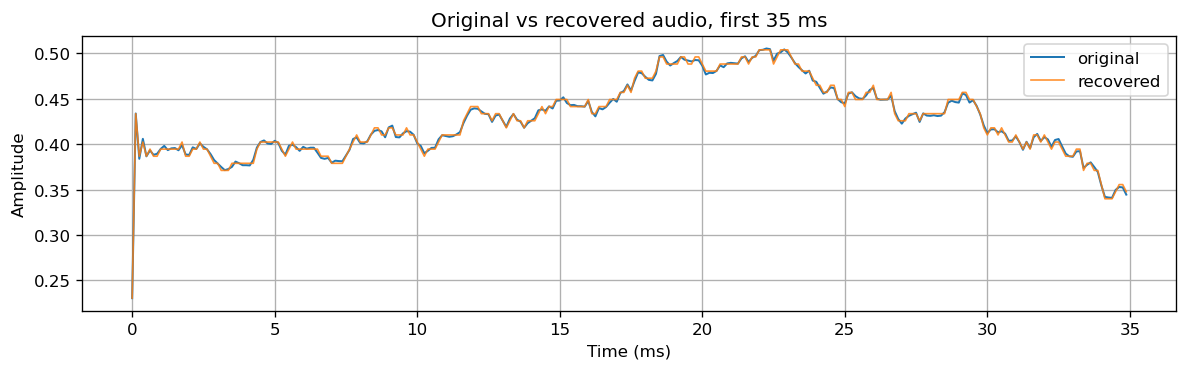

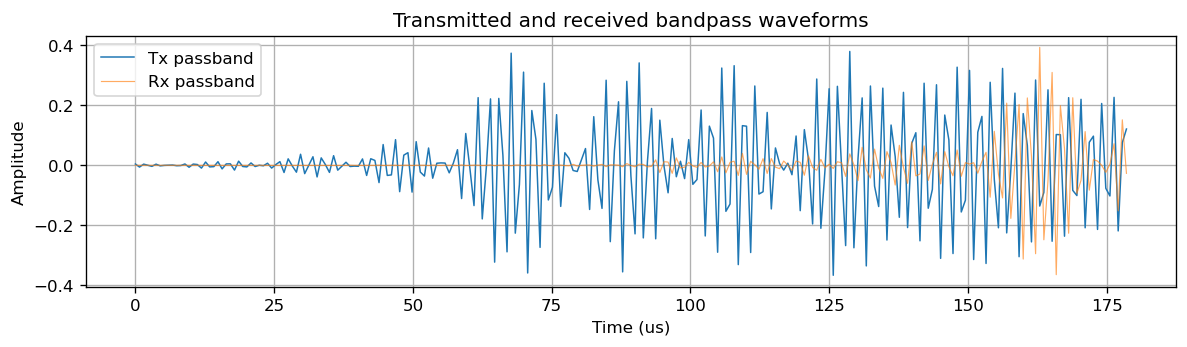

In [8]:
display(Markdown("**基础系统恢复语音试听**"))
display(Audio(baseline["recovered"], rate=AUDIO_FS))

view_ms = 35
n_view = int(AUDIO_FS * view_ms / 1000)
plt.figure(figsize=(10, 3.2))
plt.plot(t_audio[:n_view] * 1000, audio[:n_view], label="original", lw=1.2)
plt.plot(t_audio[:n_view] * 1000, baseline["recovered"][:n_view], label="recovered", lw=1.0, alpha=0.85)
plt.title("Original vs recovered audio, first 35 ms")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

samples = int(0.00018 * FS_PASS)
tt = np.arange(samples) / FS_PASS * 1e6
plt.figure(figsize=(10, 3.0))
plt.plot(tt, baseline["tx_pass"][:samples], lw=0.9, label="Tx passband")
plt.plot(tt, baseline["rx_pass"][:samples], lw=0.7, alpha=0.65, label="Rx passband")
plt.title("Transmitted and received bandpass waveforms")
plt.xlabel("Time (us)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

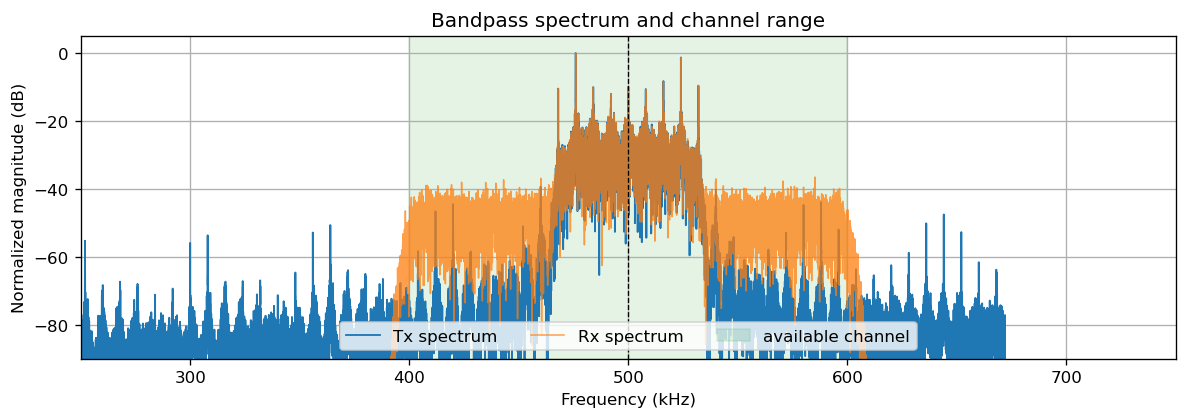

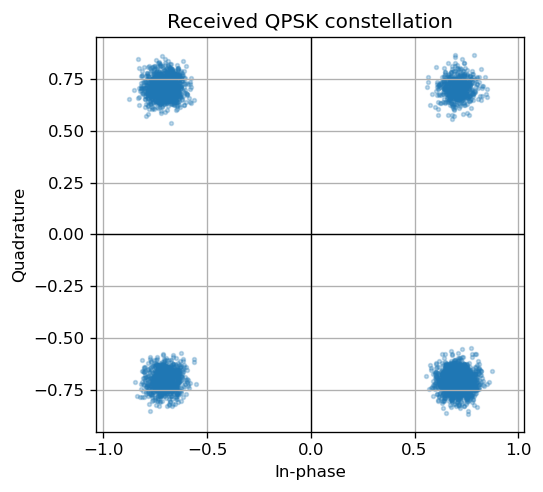

In [9]:
f_tx, db_tx = spectrum_db(baseline["tx_pass"], FS_PASS)
f_rx, db_rx = spectrum_db(baseline["rx_pass"], FS_PASS)

plt.figure(figsize=(10, 3.6))
plt.plot(f_tx / 1e3, db_tx, label="Tx spectrum", lw=1.1)
plt.plot(f_rx / 1e3, db_rx, label="Rx spectrum", lw=0.9, alpha=0.75)
plt.axvspan(F_LO / 1e3, F_HI / 1e3, color="tab:green", alpha=0.12, label="available channel")
plt.axvline(FC / 1e3, color="k", ls="--", lw=0.8)
plt.xlim(250, 750)
plt.ylim(-90, 5)
plt.title("Bandpass spectrum and channel range")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Normalized magnitude (dB)")
plt.legend(loc="lower center", ncol=3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(4.6, 4.2))
take = slice(0, min(4000, len(baseline["rx_symbols"])))
plt.scatter(np.real(baseline["rx_symbols"][take]), np.imag(baseline["rx_symbols"][take]), s=5, alpha=0.28)
plt.axhline(0, color="k", lw=0.8)
plt.axvline(0, color="k", lw=0.8)
plt.title("Received QPSK constellation")
plt.xlabel("In-phase")
plt.ylabel("Quadrature")
plt.axis("equal")
plt.tight_layout()
plt.show()

## 8. 探究问题 1：不同调制方式的性能比较

目标：比较 BPSK、QPSK、8PSK、16QAM 的误码率、占用带宽、传输速率和恢复语音质量。

控制条件：量化位数固定为 8 bit，信道编码固定为 Hamming(7,4)，信道固定为 `500 kHz ± 100 kHz`，SNR 固定为 12 dB。

In [10]:
modulations = ["BPSK", "QPSK", "8PSK", "16QAM"]
mod_results = {
    m: simulate_system(audio, nbits=8, snr_db=EXPLORE_SNR_DB, modulation=m, use_coding=True, keep_traces=True)
    for m in modulations
}

mod_df = pd.DataFrame([result_row(mod_results[m]) for m in modulations])
mod_df

,量化位数,调制,编码,SNR/dB,源比特率/kbps,发送比特率/kbps,符号率/kbaud,占用带宽/kHz,频谱效率/bps/Hz,译码前BER,译码后BER,量化SNR/dB,恢复SNR/dB,满足200kHz
0,8,BPSK,"Hamming(7,4)",12.0,64.0,112.0,112.000000,140.000000,0.457143,0.000000,0.0,38.187047,38.187047,True
1,8,QPSK,"Hamming(7,4)",12.0,64.0,112.0,56.000000,70.000000,0.914286,0.000000,0.0,38.187047,38.187047,True
2,8,8PSK,"Hamming(7,4)",12.0,64.0,112.0,37.333333,46.666667,1.371429,0.000000,0.0,38.187047,38.187047,True
3,8,16QAM,"Hamming(7,4)",12.0,64.0,112.0,28.000000,35.000000,1.828571,0.000011,0.0,38.187047,38.187047,True


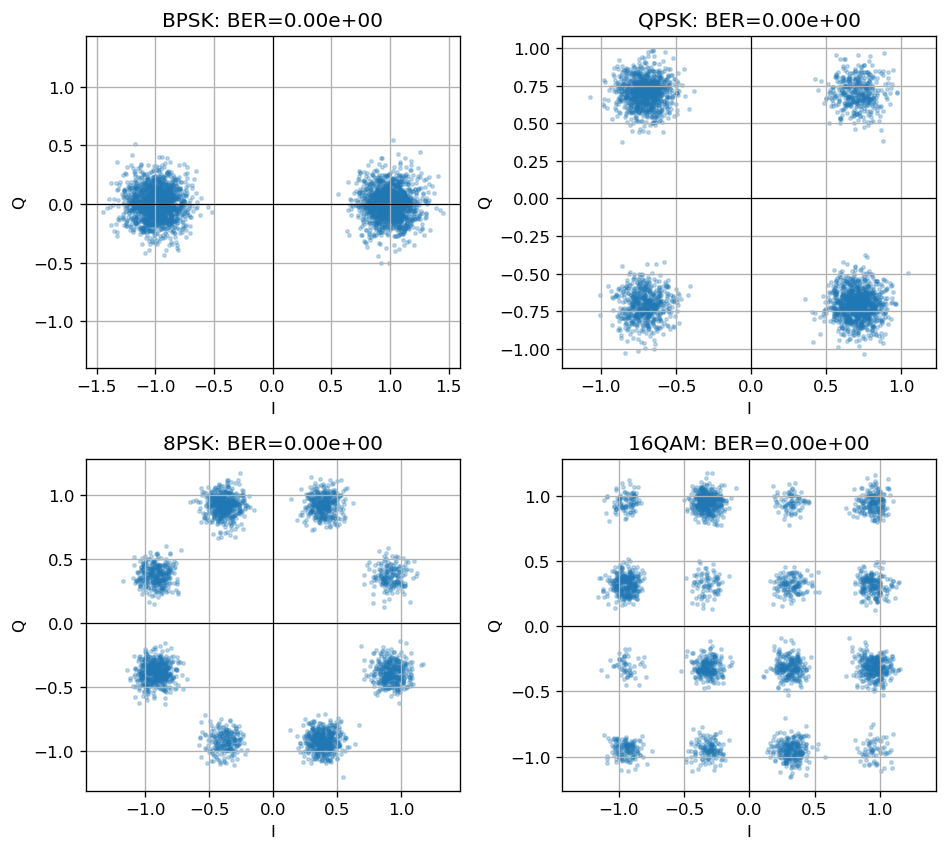

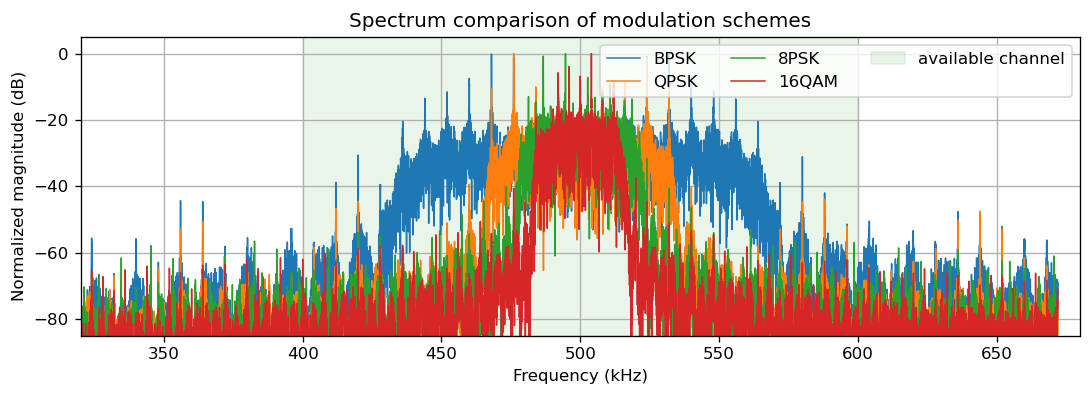

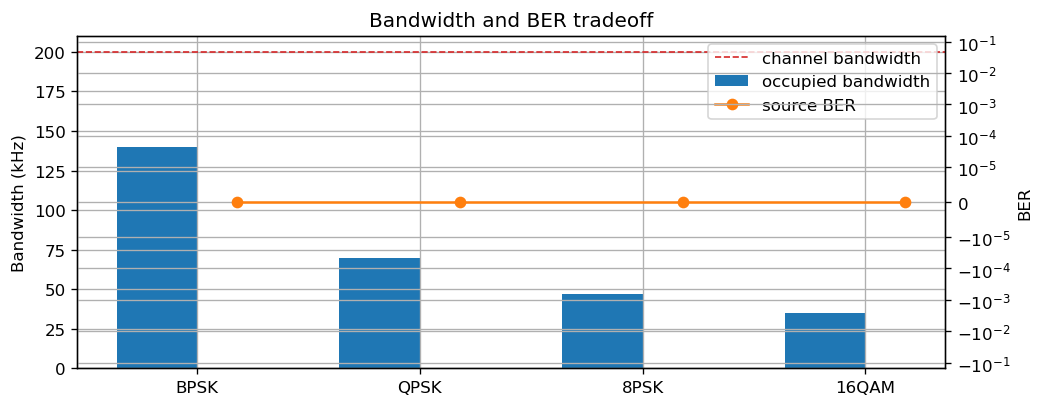

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(8, 7.2))
axes = axes.ravel()
for ax, m in zip(axes, modulations):
    r = mod_results[m]
    take = slice(0, min(3000, len(r["rx_symbols"])))
    ax.scatter(np.real(r["rx_symbols"][take]), np.imag(r["rx_symbols"][take]), s=4, alpha=0.25)
    ax.axhline(0, color="k", lw=0.7)
    ax.axvline(0, color="k", lw=0.7)
    ax.set_title(f"{m}: BER={r['source_ber_after_decoding']:.2e}")
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
    ax.axis("equal")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9.2, 3.4))
for m in modulations:
    f, db = spectrum_db(mod_results[m]["tx_pass"], FS_PASS)
    plt.plot(f / 1e3, db, lw=0.9, label=m)
plt.axvspan(F_LO / 1e3, F_HI / 1e3, color="tab:green", alpha=0.10, label="available channel")
plt.xlim(320, 680)
plt.ylim(-85, 5)
plt.title("Spectrum comparison of modulation schemes")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Normalized magnitude (dB)")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(8.8, 3.5))
x = np.arange(len(modulations))
ax1.bar(x - 0.18, [mod_results[m]["occupied_bw_hz"] / 1e3 for m in modulations], width=0.36, label="occupied bandwidth")
ax1.axhline(CHANNEL_BW / 1e3, color="tab:red", ls="--", lw=1.0, label="channel bandwidth")
ax1.set_ylabel("Bandwidth (kHz)")
ax1.set_xticks(x)
ax1.set_xticklabels(modulations)
ax2 = ax1.twinx()
ax2.plot(x + 0.18, [mod_results[m]["source_ber_after_decoding"] for m in modulations], color="tab:orange", marker="o", label="source BER")
ax2.set_yscale("symlog", linthresh=1e-5)
ax2.set_ylabel("BER")
ax1.set_title("Bandwidth and BER tradeoff")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()

**探究 1 结论：** 在相同净信息率下，BPSK 每个符号只传 1 bit，因此符号率和占用带宽最大，但抗噪声能力最好；QPSK 在抗噪声能力和频谱效率之间较均衡；8PSK 和 16QAM 每个符号承载更多 bit，占用带宽更小，但星座点间距更近，在相同 SNR 下更容易误判。频谱效率提升与抗噪声性能下降之间存在明确折中。

## 9. 探究问题 2：信道编码的作用分析

目标：比较无信道编码和有 Hamming(7,4) 编码时的 BER 与恢复语音质量。

控制条件：量化位数固定为 8 bit，调制方式固定为 QPSK，只改变是否启用 Hamming(7,4) 编码。为观察趋势，对多个 SNR 点进行扫描。

In [12]:
coding_snr_values = [6, 8, 10, 12, 14, 16]
coding_results = []
for snr in coding_snr_values:
    coding_results.append(simulate_system(audio, nbits=8, snr_db=snr, modulation="QPSK", use_coding=False, keep_traces=False))
    coding_results.append(simulate_system(audio, nbits=8, snr_db=snr, modulation="QPSK", use_coding=True, keep_traces=False))

coding_df = pd.DataFrame([result_row(r) for r in coding_results])
coding_df

,量化位数,调制,编码,SNR/dB,源比特率/kbps,发送比特率/kbps,符号率/kbaud,占用带宽/kHz,频谱效率/bps/Hz,译码前BER,译码后BER,量化SNR/dB,恢复SNR/dB,满足200kHz
0,8,QPSK,None,6,64.0,64.0,32.0,40.0,1.600000,0.000000,0.0,38.187047,38.187047,True
1,8,QPSK,"Hamming(7,4)",6,64.0,112.0,56.0,70.0,0.914286,0.000045,0.0,38.187047,38.187047,True
2,8,QPSK,None,8,64.0,64.0,32.0,40.0,1.600000,0.000000,0.0,38.187047,38.187047,True
3,8,QPSK,"Hamming(7,4)",8,64.0,112.0,56.0,70.0,0.914286,0.000000,0.0,38.187047,38.187047,True
4,8,QPSK,None,10,64.0,64.0,32.0,40.0,1.600000,0.000000,0.0,38.187047,38.187047,True
5,8,QPSK,"Hamming(7,4)",10,64.0,112.0,56.0,70.0,0.914286,0.000000,0.0,38.187047,38.187047,True
6,8,QPSK,None,12,64.0,64.0,32.0,40.0,1.600000,0.000000,0.0,38.187047,38.187047,True
7,8,QPSK,"Hamming(7,4)",12,64.0,112.0,56.0,70.0,0.914286,0.000000,0.0,38.187047,38.187047,True
8,8,QPSK,None,14,64.0,64.0,32.0,40.0,1.600000,0.000000,0.0,38.187047,38.187047,True
9,8,QPSK,"Hamming(7,4)",14,64.0,112.0,56.0,70.0,0.914286,0.000000,0.0,38.187047,38.187047,True


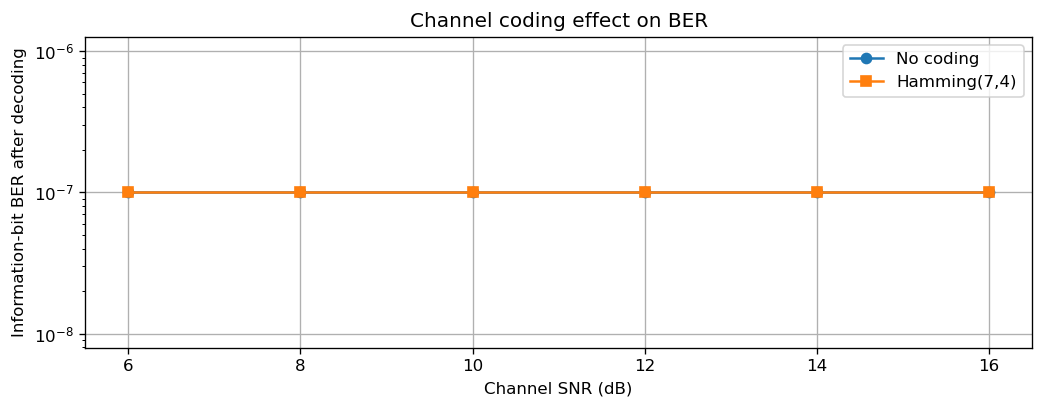

,编码方式,源比特率/kbps,发送比特率/kbps,占用带宽/kHz,译码后BER,恢复SNR/dB
0,None,64.0,64.0,40.0,0.0,38.187047
1,"Hamming(7,4)",64.0,112.0,70.0,0.0,38.187047


In [13]:
plt.figure(figsize=(8.8, 3.5))
for use_coding, label, marker in [(False, "No coding", "o"), (True, "Hamming(7,4)", "s")]:
    rows = [r for r in coding_results if r["use_coding"] == use_coding]
    plt.plot(
        [r["snr_db"] for r in rows],
        [max(r["source_ber_after_decoding"], 1e-7) for r in rows],
        marker=marker,
        label=label,
    )
plt.yscale("log")
plt.xlabel("Channel SNR (dB)")
plt.ylabel("Information-bit BER after decoding")
plt.title("Channel coding effect on BER")
plt.legend()
plt.tight_layout()
plt.show()

coding_rate_rows = []
for use_coding in [False, True]:
    r = simulate_system(audio, nbits=8, snr_db=EXPLORE_SNR_DB, modulation="QPSK", use_coding=use_coding, keep_traces=False)
    coding_rate_rows.append(
        {
            "编码方式": r["coding_name"],
            "源比特率/kbps": r["source_bitrate_bps"] / 1e3,
            "发送比特率/kbps": r["tx_bitrate_bps"] / 1e3,
            "占用带宽/kHz": r["occupied_bw_hz"] / 1e3,
            "译码后BER": r["source_ber_after_decoding"],
            "恢复SNR/dB": r["recovered_snr_db"],
        }
    )
pd.DataFrame(coding_rate_rows)

**探究 2 结论：** Hamming(7,4) 可以纠正单比特错误，因此在中低 SNR 下通常能降低信息比特 BER，恢复语音也更稳定；代价是码率从 1 下降到 4/7，发送比特率扩大为原来的 7/4。在 QPSK 下，这会让符号率和占用带宽随之增加。也就是说，信道编码用带宽或传输时间换可靠性。

## 10. 探究问题 3：量化位数对语音恢复质量的影响

目标：比较 4 bit、6 bit、8 bit、12 bit PCM 对语音波形、听感、量化噪声、系统比特率和恢复质量的影响。

控制条件：调制方式固定为 QPSK，信道编码固定为 Hamming(7,4)，信道 SNR 固定为 18 dB。

In [14]:
bit_depths = [4, 6, 8, 12]
quant_results = {
    b: simulate_system(audio, nbits=b, snr_db=BASELINE_SNR_DB, modulation="QPSK", use_coding=True, keep_traces=False)
    for b in bit_depths
}

quant_df = pd.DataFrame([result_row(quant_results[b]) for b in bit_depths])
quant_df

,量化位数,调制,编码,SNR/dB,源比特率/kbps,发送比特率/kbps,符号率/kbaud,占用带宽/kHz,频谱效率/bps/Hz,译码前BER,译码后BER,量化SNR/dB,恢复SNR/dB,满足200kHz
0,4,QPSK,"Hamming(7,4)",18.0,32.0,56.0,28.0,35.0,0.914286,0.0,0.0,14.075824,14.075824,True
1,6,QPSK,"Hamming(7,4)",18.0,48.0,84.0,42.0,52.5,0.914286,0.0,0.0,26.125017,26.125017,True
2,8,QPSK,"Hamming(7,4)",18.0,64.0,112.0,56.0,70.0,0.914286,0.0,0.0,38.187047,38.187047,True
3,12,QPSK,"Hamming(7,4)",18.0,96.0,168.0,84.0,105.0,0.914286,0.0,0.0,62.262468,62.262468,True


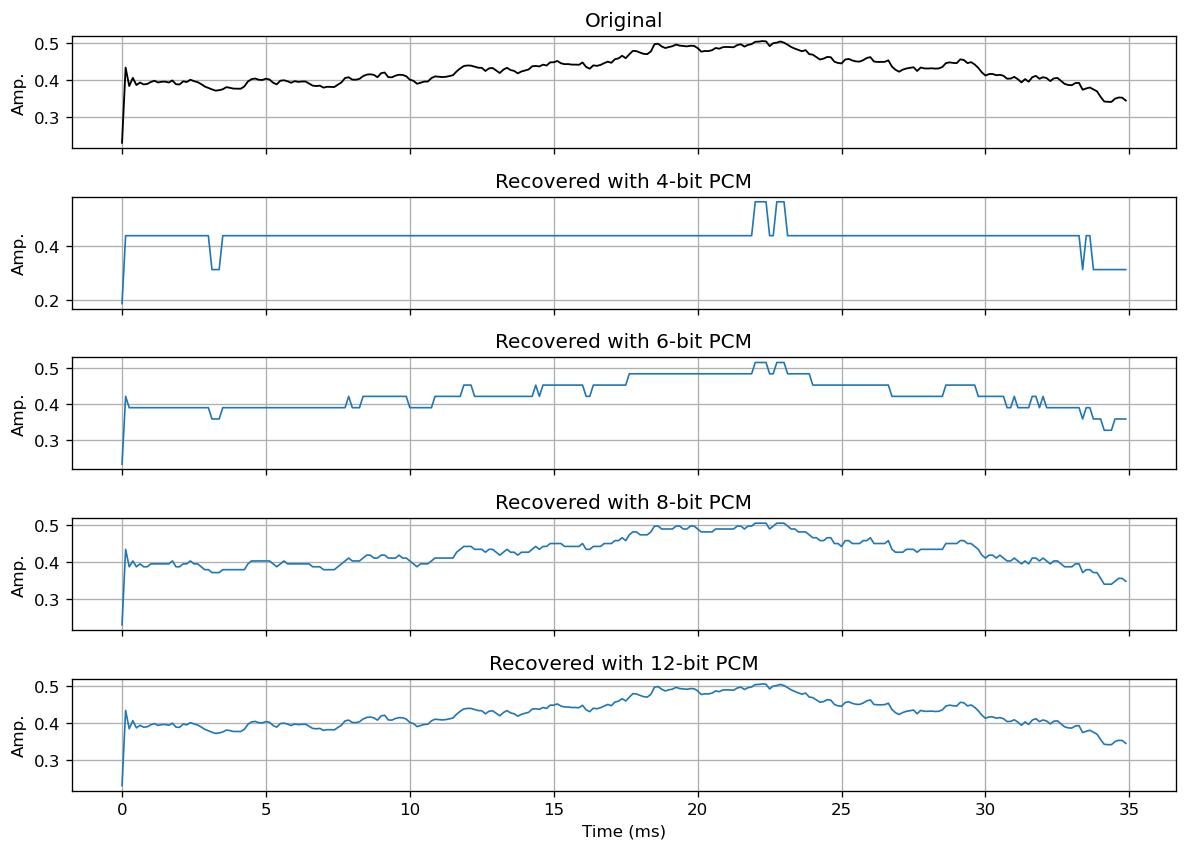

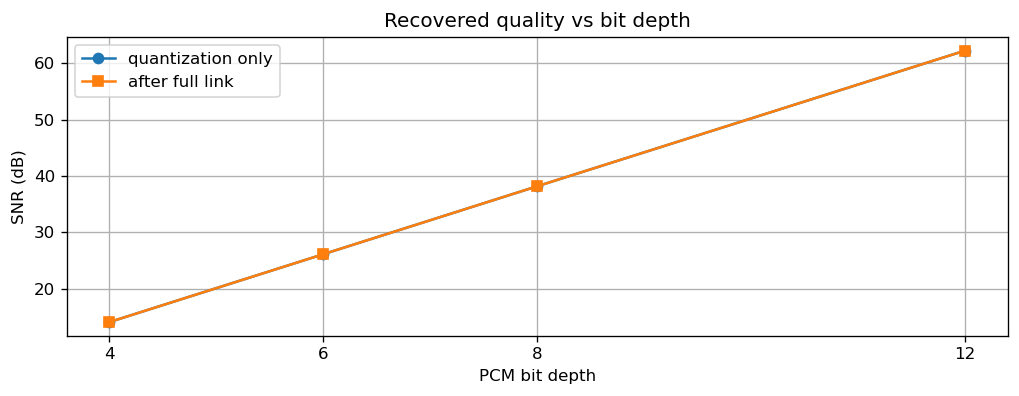

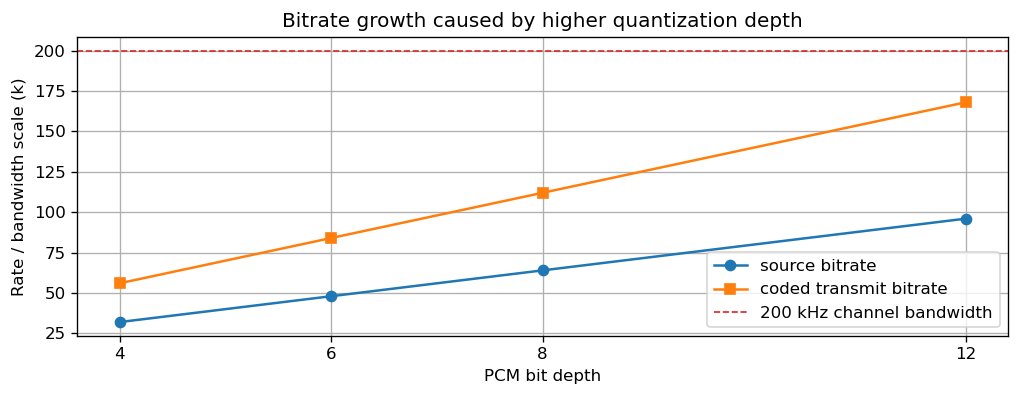

In [15]:
fig, axes = plt.subplots(len(bit_depths) + 1, 1, figsize=(10, 7.2), sharex=True)
axes[0].plot(t_audio[:n_view] * 1000, audio[:n_view], color="k", lw=1.1)
axes[0].set_title("Original")
axes[0].set_ylabel("Amp.")

for ax, b in zip(axes[1:], bit_depths):
    ax.plot(t_audio[:n_view] * 1000, quant_results[b]["recovered"][:n_view], lw=1.0)
    ax.set_title(f"Recovered with {b}-bit PCM")
    ax.set_ylabel("Amp.")

axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.6, 3.4))
plt.plot(bit_depths, [quant_results[b]["quantization_snr_db"] for b in bit_depths], marker="o", label="quantization only")
plt.plot(bit_depths, [quant_results[b]["recovered_snr_db"] for b in bit_depths], marker="s", label="after full link")
plt.xlabel("PCM bit depth")
plt.ylabel("SNR (dB)")
plt.title("Recovered quality vs bit depth")
plt.xticks(bit_depths)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.6, 3.4))
plt.plot(bit_depths, [quant_results[b]["source_bitrate_bps"] / 1e3 for b in bit_depths], marker="o", label="source bitrate")
plt.plot(bit_depths, [quant_results[b]["tx_bitrate_bps"] / 1e3 for b in bit_depths], marker="s", label="coded transmit bitrate")
plt.axhline(CHANNEL_BW / 1e3, color="tab:red", ls="--", lw=1.0, label="200 kHz channel bandwidth")
plt.xlabel("PCM bit depth")
plt.ylabel("Rate / bandwidth scale (k)")
plt.title("Bitrate growth caused by higher quantization depth")
plt.xticks(bit_depths)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
for b in bit_depths:
    display(Markdown(f"**{b} bit PCM 恢复语音**"))
    display(Audio(quant_results[b]["recovered"], rate=AUDIO_FS))

**4 bit PCM 恢复语音**

**6 bit PCM 恢复语音**

**8 bit PCM 恢复语音**

**12 bit PCM 恢复语音**

**探究 3 结论：** 量化位数越高，量化噪声越小，语音波形细节保留越好；但源比特率按 `采样率 × 量化位数` 线性增加，经过 Hamming(7,4) 后发送比特率还会变为原来的 7/4。因此量化位数体现了“语音质量”和“传输效率”的权衡。当前参数下 8 bit 是较均衡选择，12 bit 质量更高但占用更多系统资源。

## 11. 探究问题 4：系统瓶颈分析

目标：基于完整系统判断当前性能主要受哪个模块限制，并给出数据或图形支撑。

判断思路：

- 如果译码后 BER 接近 0，而恢复 SNR 与纯量化 SNR 几乎相同，说明主要瓶颈是量化；
- 如果提高调制阶数后 BER 明显上升，说明在低 SNR 或高阶调制下瓶颈会转移到调制/信道；
- 如果占用带宽接近 200 kHz，说明带宽约束会成为系统瓶颈。

In [17]:
bottleneck_rows = []

for b in bit_depths:
    r = quant_results[b]
    bottleneck_rows.append(
        {
            "实验点": f"{b} bit, QPSK, coded",
            "译码后BER": r["source_ber_after_decoding"],
            "量化SNR/dB": r["quantization_snr_db"],
            "恢复SNR/dB": r["recovered_snr_db"],
            "链路额外损失/dB": r["quantization_snr_db"] - r["recovered_snr_db"],
            "带宽余量/kHz": CHANNEL_BW / 1e3 - r["occupied_bw_hz"] / 1e3,
        }
    )

for m in modulations:
    r = mod_results[m]
    bottleneck_rows.append(
        {
            "实验点": f"8 bit, {m}, coded, {EXPLORE_SNR_DB:g} dB",
            "译码后BER": r["source_ber_after_decoding"],
            "量化SNR/dB": r["quantization_snr_db"],
            "恢复SNR/dB": r["recovered_snr_db"],
            "链路额外损失/dB": r["quantization_snr_db"] - r["recovered_snr_db"],
            "带宽余量/kHz": CHANNEL_BW / 1e3 - r["occupied_bw_hz"] / 1e3,
        }
    )

bottleneck_df = pd.DataFrame(bottleneck_rows)
bottleneck_df

,实验点,译码后BER,量化SNR/dB,恢复SNR/dB,链路额外损失/dB,带宽余量/kHz
0,"4 bit, QPSK, coded",0.0,14.075824,14.075824,0.0,165.000000
1,"6 bit, QPSK, coded",0.0,26.125017,26.125017,0.0,147.500000
2,"8 bit, QPSK, coded",0.0,38.187047,38.187047,0.0,130.000000
3,"12 bit, QPSK, coded",0.0,62.262468,62.262468,0.0,95.000000
4,"8 bit, BPSK, coded, 12 dB",0.0,38.187047,38.187047,0.0,60.000000
5,"8 bit, QPSK, coded, 12 dB",0.0,38.187047,38.187047,0.0,130.000000
6,"8 bit, 8PSK, coded, 12 dB",0.0,38.187047,38.187047,0.0,153.333333
7,"8 bit, 16QAM, coded, 12 dB",0.0,38.187047,38.187047,0.0,165.000000


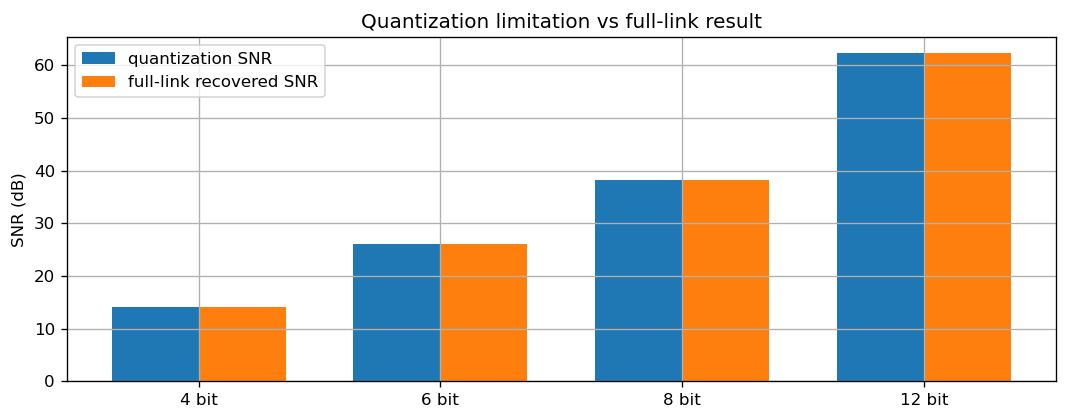

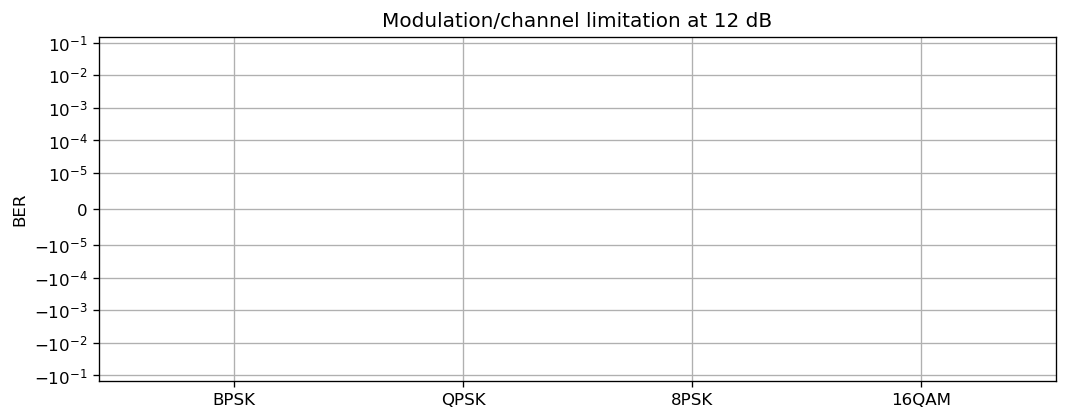

In [18]:
plt.figure(figsize=(9.0, 3.6))
labels = [f"{b} bit" for b in bit_depths]
plt.bar(np.arange(len(bit_depths)) - 0.18, [quant_results[b]["quantization_snr_db"] for b in bit_depths], width=0.36, label="quantization SNR")
plt.bar(np.arange(len(bit_depths)) + 0.18, [quant_results[b]["recovered_snr_db"] for b in bit_depths], width=0.36, label="full-link recovered SNR")
plt.xticks(np.arange(len(bit_depths)), labels)
plt.ylabel("SNR (dB)")
plt.title("Quantization limitation vs full-link result")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9.0, 3.6))
plt.bar(modulations, [mod_results[m]["source_ber_after_decoding"] for m in modulations])
plt.yscale("symlog", linthresh=1e-5)
plt.ylabel("BER")
plt.title(f"Modulation/channel limitation at {EXPLORE_SNR_DB:g} dB")
plt.tight_layout()
plt.show()

In [19]:
base_loss = baseline["quantization_snr_db"] - baseline["recovered_snr_db"]
base_margin = CHANNEL_BW / 1e3 - baseline["occupied_bw_hz"] / 1e3

if baseline["source_ber_after_decoding"] < 1e-5 and abs(base_loss) < 1.0:
    main_bottleneck = "8 bit PCM 量化"
    reason = "基础系统译码后 BER 近似为 0，完整链路恢复 SNR 与纯量化 SNR 几乎一致，说明信道和调制没有成为主要限制。"
else:
    main_bottleneck = "信道噪声/调制判决"
    reason = "基础系统仍存在明显译码后 BER 或链路额外损失，说明误码已经显著影响恢复质量。"

summary_text = (
    f"**瓶颈判断：当前基础系统的主要瓶颈是 `{main_bottleneck}`。**\n\n"
    f"- 判断依据：{reason}\n"
    f"- 基础系统带宽余量约 `{base_margin:.1f} kHz`，因此在 8 bit + QPSK + Hamming(7,4) 参数下，带宽不是主要瓶颈。\n"
    "- 当调制阶数提高到 8PSK/16QAM 或信道 SNR 降低时，星座点间距变小，瓶颈会逐渐转移到调制判决与信道噪声。\n"
    "- 改进方案 1：若带宽允许，可把 8 bit PCM 提升到 12 bit，提高量化 SNR；代价是源比特率和发送比特率增加。\n"
    "- 改进方案 2：若要节省带宽，可保留 8 bit 或使用语音压缩编码；代价是系统复杂度增加。\n"
    "- 改进方案 3：若信道条件较差，可使用更强纠错码或降低调制阶数；代价是频谱效率下降。\n"
)
display(Markdown(summary_text))

**瓶颈判断：当前基础系统的主要瓶颈是 `8 bit PCM 量化`。**

- 判断依据：基础系统译码后 BER 近似为 0，完整链路恢复 SNR 与纯量化 SNR 几乎一致，说明信道和调制没有成为主要限制。
- 基础系统带宽余量约 `130.0 kHz`，因此在 8 bit + QPSK + Hamming(7,4) 参数下，带宽不是主要瓶颈。
- 当调制阶数提高到 8PSK/16QAM 或信道 SNR 降低时，星座点间距变小，瓶颈会逐渐转移到调制判决与信道噪声。
- 改进方案 1：若带宽允许，可把 8 bit PCM 提升到 12 bit，提高量化 SNR；代价是源比特率和发送比特率增加。
- 改进方案 2：若要节省带宽，可保留 8 bit 或使用语音压缩编码；代价是系统复杂度增加。
- 改进方案 3：若信道条件较差，可使用更强纠错码或降低调制阶数；代价是频谱效率下降。


## 12. 四个探究题总结合并

1. **调制方式比较**：BPSK 抗噪声最好但占用带宽最大；QPSK 折中较好；8PSK/16QAM 频谱效率高但更依赖高 SNR。
2. **信道编码作用**：Hamming(7,4) 能降低信息比特 BER，提高可靠性；代价是发送比特率和占用带宽增加。
3. **量化位数影响**：位数越高量化噪声越小，恢复语音质量越好；代价是系统比特率上升。
4. **系统瓶颈**：在基础参数下主要瓶颈是 PCM 量化；在低 SNR 或高阶调制下，瓶颈会转移到信道噪声和星座判决。